# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** Y . Sandhya    
**Register Number:** AP24110011857  
**Date:** 22/08/2026

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [2]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [3]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [4]:
# Write your answer here

tips_tip_missing = tips.copy()

np.random.seed(42)
missing_idx = np.random.choice(tips_tip_missing.index, size=5, replace=False)
tips_tip_missing.loc[missing_idx, 'tip'] = np.nan

time_medians = tips_tip_missing.groupby('time')['tip'].transform('median')

tips_tip_missing['tip'] = tips_tip_missing['tip'].fillna(time_medians)

print("Remaining missing values:", tips_tip_missing['tip'].isna().sum())

tips_tip_missing.head()

Remaining missing values: 0


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*Group-wise filling can preserve differences between different groups in the data. For example, if dinner tips are generally higher than lunch tips, filling a missing dinner tip with the overall median could give an inaccurate value, while using the dinner median would be more appropriate.


## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [5]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [6]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*
I would use label encoding for time because it has only two categories, Lunch and Dinner. Since it is a binary categorical variable, it can be represented using 0 and 1.

In [7]:
# Write your answer here
tips_enc['time_encoded'] = tips_enc['time'].map({
    'Lunch': 0,
    'Dinner': 1
})

tips_enc[['time', 'time_encoded']].head()

,time,time_encoded
0,Dinner,1
1,Dinner,1
2,Dinner,1
3,Dinner,1
4,Dinner,1


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*Label encoding day as 0, 1, 2, and 3 can be misleading because these numbers may make the model assume that the days have a meaningful order or numerical relationship. However, the days are categorical values with no such ranking, so one-hot encoding is more appropriate.


## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [8]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [9]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*After standardization, the mean of total_bill_standardized should be approximately 0 and the standard deviation should be approximately 1.

Now apply **min-max scaling** to the `size` column and store it as `size_scaled`.


In [10]:
# Write your answer here

print("Mean:", tips_enc['total_bill_standardized'].mean())
print("Standard deviation:", tips_enc['total_bill_standardized'].std())


tips_enc['size_scaled'] = min_max_scale(tips_enc['size'])


tips_enc[['size', 'size_scaled']].head()

Mean: -6.028875031263658e-17
Standard deviation: 1.0


,size,size_scaled
0,2,0.2
1,3,0.4
2,3,0.4
3,2,0.2
4,4,0.6


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*
Min-Max Scaling is useful when we want all values within a fixed range such as 0 to 1. Standardization is useful when we want the data centered around a mean of 0 with a standard deviation of 1. Extreme outliers can affect Min-Max Scaling strongly because it depends directly on the minimum and maximum values.

## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [11]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


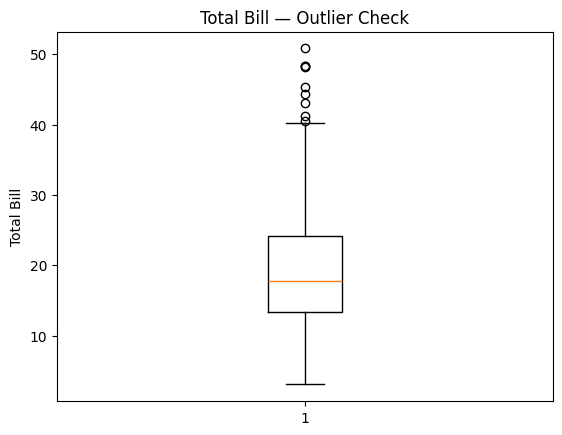

In [12]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [13]:
# Write your answer here
# Calculate Q1, Q3 and IQR for tip
Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)

IQR = Q3 - Q1

# Calculate the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
tip_outliers = tips[
    (tips['tip'] < lower_bound) |
    (tips['tip'] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(tip_outliers))

# Create a copy for capping
tips_capped = tips.copy()

# Cap the outliers
tips_capped['tip'] = tips_capped['tip'].clip(
    lower=lower_bound,
    upper=upper_bound
)

tips_capped[['tip']].head()

Lower bound: -0.34375
Upper bound: 5.90625
Number of outliers: 9


,tip
0,1.01
1,1.66
2,3.50
3,3.31
4,3.61


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*
Capping outliers can be preferable because it keeps the complete row and does not reduce the amount of data available for training. It is useful when the outlier is a valid observation but is unusually extreme. Dropping may be better when the outlier is caused by an error, such as an incorrect measurement or data-entry mistake.

## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [14]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [15]:
# Write your answer here

train_70, test_30 = train_test_split(
    tips,
    test_size=0.3,
    random_state=42
)

print("Training rows:", len(train_70))
print("Testing rows:", len(test_30))

Training rows: 170
Testing rows: 74


random_state controls the randomness used while splitting the dataset. Setting it to 42 makes the split reproducible, meaning we get the same training and testing rows each time we run the code. The number 42 itself has no special mathematical meaning; it is simply a commonly used fixed value.

**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*
It is important to split the data before training so that the test set remains unseen by the model. This allows us to evaluate the model fairly on new data and determine how well it can generalize.

# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-03-05 185220.png to Screenshot 2026-03-05 185220.png
Saving Screenshot 2026-03-05 185740.png to Screenshot 2026-03-05 185740.png
Saving Screenshot 2026-03-05 190029.png to Screenshot 2026-03-05 190029.png
Saving Screenshot 2026-05-20 154953.png to Screenshot 2026-05-20 154953.png
Saving Screenshot 2026-05-20 155006.png to Screenshot 2026-05-20 155006.png


In [3]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [6]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd

filenames = list(uploaded.keys())

normalized_images = []
image_data = []

for filename in filenames:
    # Open image
    img = Image.open(filename).convert("RGB")
    img_array = np.array(img)

    # Before normalization
    min_before = img_array.min()
    max_before = img_array.max()

    # Normalize pixels from 0-255 to 0-1
    normalized = img_array / 255.0

    # Store normalized image
    normalized_images.append(normalized)

    # After normalization
    min_after = normalized.min()
    max_after = normalized.max()

    # Store information
    image_data.append({
        "filename": filename,
        "min_pixel_before": min_before,
        "max_pixel_before": max_before,
        "min_pixel_after": min_after,
        "max_pixel_after": max_after
    })

# Create DataFrame
image_df = pd.DataFrame(image_data)

image_df

,filename,min_pixel_before,max_pixel_before,min_pixel_after,max_pixel_after
0,Screenshot 2026-03-05 185220.png,0,254,0.0,0.996078
1,Screenshot 2026-03-05 185740.png,0,255,0.0,1.000000
2,Screenshot 2026-03-05 190029.png,0,255,0.0,1.000000
3,Screenshot 2026-05-20 154953.png,0,255,0.0,1.000000
4,Screenshot 2026-05-20 155006.png,0,255,0.0,1.000000


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [7]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (765, 1661, 3)
Resized shape: (128, 128, 4)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [8]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd

resized_images = []
image_data = []

filenames = list(uploaded.keys())

for filename in filenames:
    # Open image
    img = Image.open(filename).convert("RGB")

    # Resize to 128 × 128
    resized = img.resize((128, 128))

    # Convert to NumPy array and normalize to 0-1
    normalized = np.array(resized) / 255.0

    # Store normalized array
    resized_images.append(normalized)

    # Store filename and shape
    image_data.append({
        "filename": filename,
        "shape": normalized.shape
    })

# Create DataFrame
shape_df = pd.DataFrame(image_data)

shape_df

,filename,shape
0,Screenshot 2026-03-05 185220.png,"(128, 128, 3)"
1,Screenshot 2026-03-05 185740.png,"(128, 128, 3)"
2,Screenshot 2026-03-05 190029.png,"(128, 128, 3)"
3,Screenshot 2026-05-20 154953.png,"(128, 128, 3)"
4,Screenshot 2026-05-20 155006.png,"(128, 128, 3)"


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*
Every image should have the same shape because the model expects the input images to be in the same size. If the images have different sizes, the model cannot process them together properly. So we resize all the images to the same shape before giving them to the model.

# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [9]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [10]:
# Write your answer here
sentence = "Hello, I have 3 apples! This is GREAT."

# Clean the sentence
clean_text = sentence.lower()
clean_text = re.sub(r'[^\w\s]', '', clean_text)

# Convert into tokens
tokens = clean_text.split()

print(tokens)

['hello', 'i', 'have', '3', 'apples', 'this', 'is', 'great']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [11]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'3': 0, 'apples': 1, 'great': 2, 'have': 3, 'hello': 4, 'i': 5, 'is': 6, 'this': 7}
Original tokens: ['hello', 'i', 'have', '3', 'apples', 'this', 'is', 'great']
Encoded as IDs:   [4, 5, 3, 0, 1, 7, 6, 2]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [12]:
# Write your answer here
# Create word_to_id mapping
word_to_id = {word: i + 1 for i, word in enumerate(sorted(set(tokens)))}

print("word_to_id:", word_to_id)

# Encode the tokens
encoded_tokens = [word_to_id[word] for word in tokens]

print("Encoded tokens:", encoded_tokens)

# Create DataFrame
mapping_df = pd.DataFrame(
    list(word_to_id.items()),
    columns=["word", "id"]
)

# Sort by id
mapping_df = mapping_df.sort_values("id").reset_index(drop=True)

mapping_df

word_to_id: {'3': 1, 'apples': 2, 'great': 3, 'have': 4, 'hello': 5, 'i': 6, 'is': 7, 'this': 8}
Encoded tokens: [5, 6, 4, 1, 2, 8, 7, 3]


,word,id
0,3,1
1,apples,2
2,great,3
3,have,4
4,hello,5
5,i,6
6,is,7
7,this,8


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*
Yes, the same problem can happen with words. The IDs may create a misleading order between words, even though the words do not have any natural order. For example, giving one word ID 1 and another word ID 2 does not mean that the second word is greater or more important than the first. So, using word IDs directly in a model may give incorrect relationships between words.

# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

Load and understand the data – Check the columns, data types, and basic information.
Handle missing values – Fill or handle missing values using a suitable method.
Encode categorical data – Convert categorical values into numerical form using label encoding or one-hot encoding.
Detect and handle outliers – Use methods like IQR and cap extreme values if necessary.
Scale numerical features – Apply Min-Max scaling or standardization when required.
Split the data into training and testing sets – Separate the data before training the model.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

Preprocessing is part of data work because raw data is usually not directly suitable for a machine learning model. Missing values, categorical data, different numerical ranges, and outliers need to be handled properly. The model mainly learns patterns from the data given to it; it does not automatically know the correct way to clean or transform the data.

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

Image and text preprocessing work with different types of data, but the main idea is similar: both convert raw data into a numerical format that a computer or machine learning model can understand. In images, pixel values can be resized and normalized to a suitable range. In text, words can be cleaned and converted into numerical IDs or vectors. In both cases, preprocessing makes the raw input consistent and usable by the model.

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.
I am still a little unsure about when to use Min-Max scaling versus standardization. I understand that Min-Max scaling usually converts values to a fixed range, while standardization converts values based on the mean and standard deviation. I would like to understand better which one is more suitable for different machine learning algorithms.
